TLS Slope (m): -0.3522
Question 7 - Estimated Crop Field Angle (TLS): 19.40 degrees


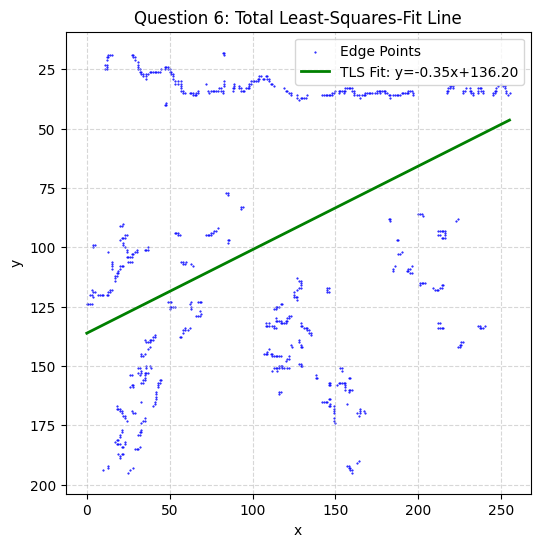

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the image
filename = 'Image of the crop field.png'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not find '{filename}'.")
else:
    #Extract the x and y coordinates
    edges = cv.Canny(img, 550, 690)
    indices = np.where(edges != 0)
    x = indices[1] # Column index
    y = indices[0] # Row index

   
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Center the data
    x_centered = x - x_mean
    y_centered = y - y_mean

    # Stack and calculate SVD
    data = np.vstack([x_centered, y_centered]).T
    u, s, vh = np.linalg.svd(data)

    # Extract the line parameters from the V matrix
    a, b = vh[1, :]

    # Calculate slope (m) and intercept (c)
    m_tls = -a / b
    c_tls = y_mean - m_tls * x_mean

    angle_tls = np.degrees(np.arctan(m_tls))
    
    print(f"TLS Slope (m): {m_tls:.4f}")
    print(f"Question 7 - Estimated Crop Field Angle (TLS): {abs(angle_tls):.2f} degrees")

    plt.figure(figsize=(6, 6))
    
    # Plot the scatter points
    plt.scatter(x, y, s=1, c='blue', marker='.', label='Edge Points')

    # Draw the green TLS line from the minimum X to maximum X
    x_plot = np.array([np.min(x), np.max(x)])
    y_plot = m_tls * x_plot + c_tls
    plt.plot(x_plot, y_plot, color='green', linewidth=2, label=f'TLS Fit: y={m_tls:.2f}x+{c_tls:.2f}')

    # Formatting
    plt.gca().invert_yaxis() 
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Question 6: Total Least-Squares-Fit Line')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()